# Individual Preprocessing Technique: Encoding Categorical Variables

**Member:** Wickrama W.M.K.E | IT25102219  
**Dataset:** Adult Income Dataset

## Objective

This notebook converts categorical values into numerical representations so that machine-learning algorithms can use every input feature. The target column `income` is label-encoded as a binary variable, while nominal predictors are one-hot encoded.

## Why encoding is required

The Adult dataset contains text categories such as occupation, relationship, race, and sex. These values cannot be used directly by most scikit-learn estimators. Label encoding is suitable for the binary target, but assigning arbitrary integer codes to nominal predictors could incorrectly imply an order. Therefore, one-hot encoding is used for the nominal feature columns.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import os


sns.set(color_codes=True)

In [12]:
df = pd.read_csv("../data/raw/adult.csv")

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

Dataset loaded successfully.
Shape of dataset: (32561, 15)


In [13]:
print("\nFirst 5 rows of the dataset")
display(df.head())

print("\nData types of each column:")
display(df.dtypes)


First 5 rows of the dataset


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K



Data types of each column:


age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

In [14]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("\nCategorical columns found:")
print(cat_cols)


Categorical columns found:
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']


C:\Users\Malan\AppData\Local\Temp\ipykernel_27784\975281046.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


## 1. Encode the target variable

`income` has only two classes, so `LabelEncoder` is appropriate here. The resulting 0/1 target is a compact representation for classification and does not impose an ordering on predictor categories.

In [15]:
le = LabelEncoder()
df["income"] = le.fit_transform(df["income"])

print("\n--------income' column encoded (0 = <=50K, 1 = >50K)--------")
print(df["income"].value_counts())



--------income' column encoded (0 = <=50K, 1 = >50K)--------
income
0    24720
1     7841
Name: count, dtype: int64


In [16]:
# Dropping 'education' here mirrors IT25300115's feature-engineering step (see their notebook for justification)
df = df.drop(columns=["education"])

print("\n--------Columns AFTER dropping 'education'---------")
display(df.columns.tolist())

if "education" not in df.columns:
    print("'education' column removed successfully (per IT25300115's redundancy analysis).")



--------Columns AFTER dropping 'education'---------


['age',
 'workclass',
 'fnlwgt',
 'education.num',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital.gain',
 'capital.loss',
 'hours.per.week',
 'native.country',
 'income']

'education' column removed successfully (per IT25300115's redundancy analysis).


## 2. One-hot encode nominal predictors

The nominal predictor columns are expanded into indicator columns with `pd.get_dummies`. `drop_first=True` removes one reference category per feature and avoids perfect multicollinearity in linear models. The original `education` text column is omitted because the feature-engineering contribution retains its equivalent numeric rank, `education.num`.

In [17]:
nominal_cols = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country",
]

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True,dtype=int)

print("\nData encoded using One-Hot Encoding.")
print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)

print("\n------------First 5 rows of the final encoded dataset-----------")
display(df_encoded.head())


Data encoded using One-Hot Encoding.
Shape before encoding: (32561, 14)
Shape after encoding: (32561, 86)

------------First 5 rows of the final encoded dataset-----------


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,82,132870,9,0,4356,18,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,66,186061,10,0,4356,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,54,140359,4,0,3900,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,41,264663,10,0,3900,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0



Creating EDA charts. Saving to: c:\Users\Malan\Downloads\2026-Y2-S1-MLB-B1G1-07\results\eda_visualizations


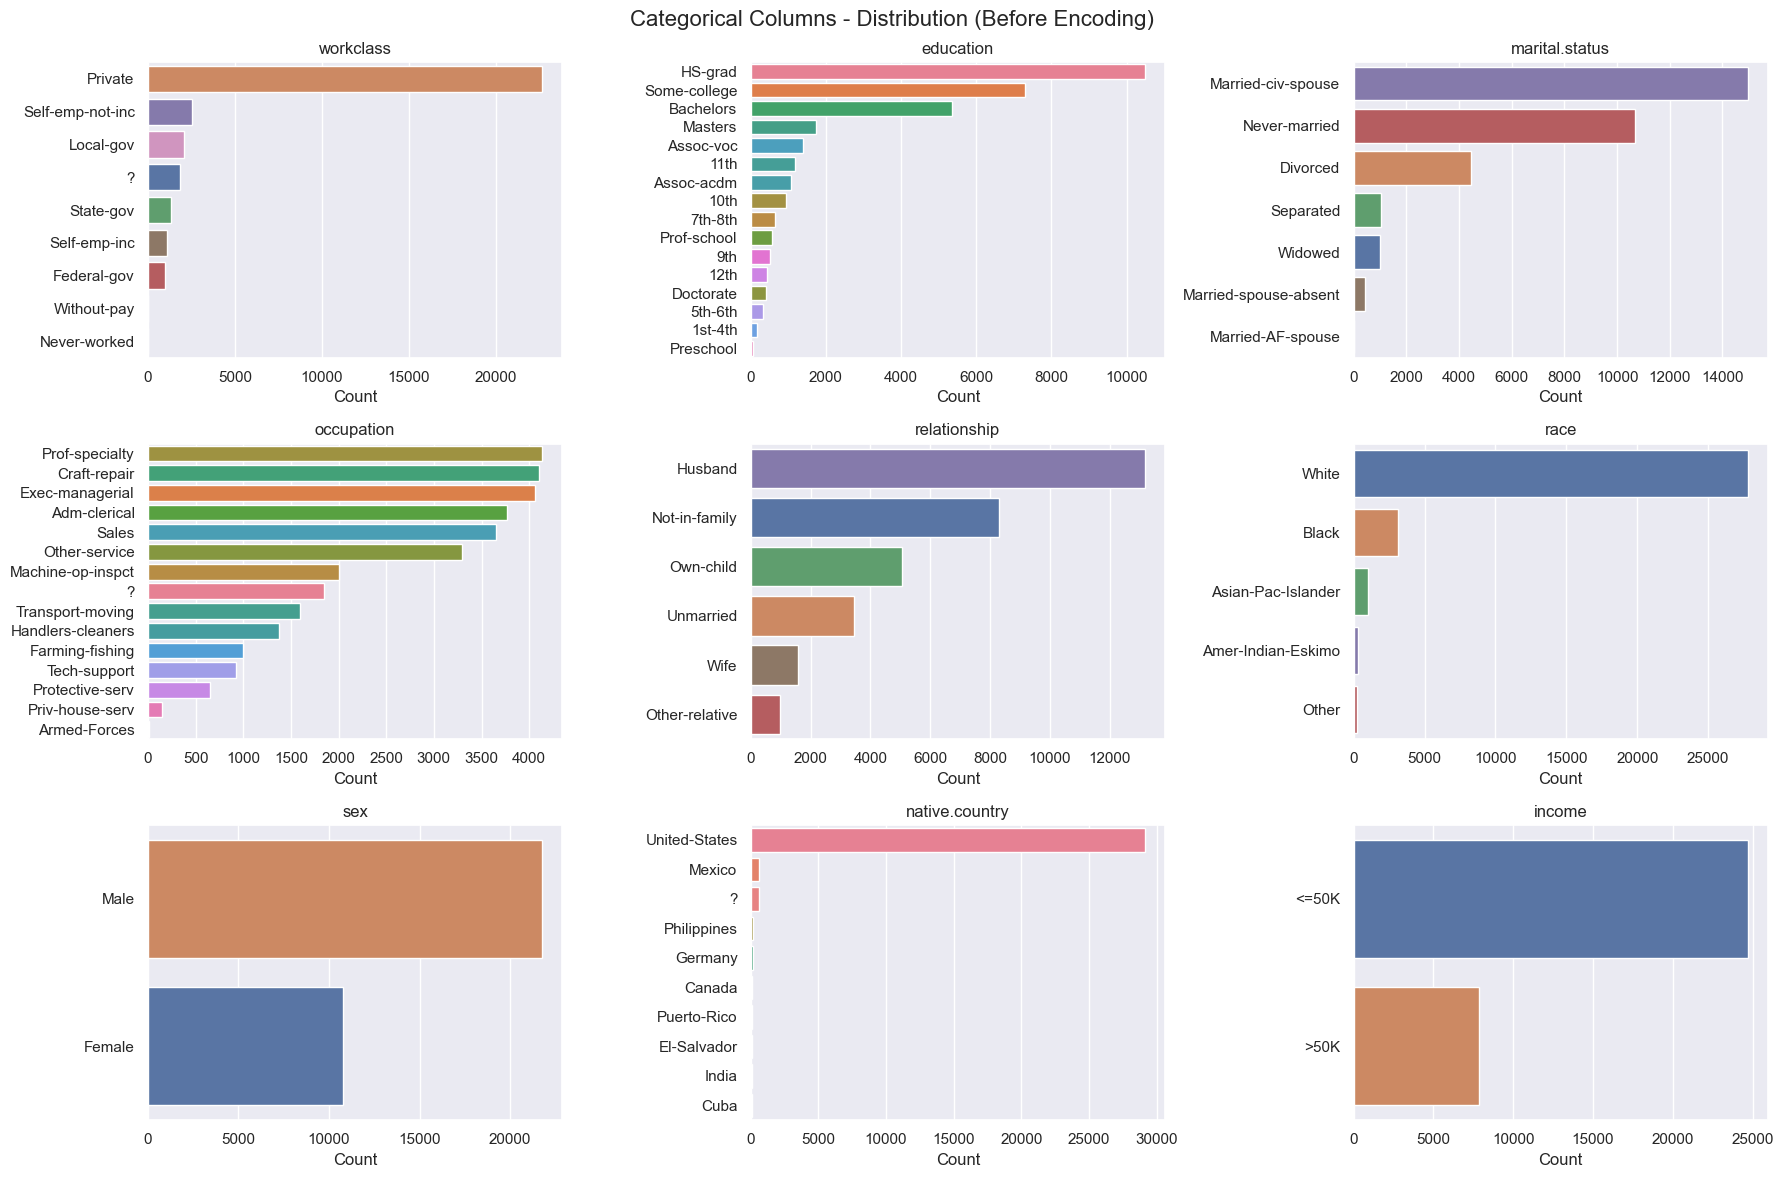

In [18]:
output_dir = os.path.abspath(os.path.join("..", "results", "eda_visualizations"))
os.makedirs(output_dir, exist_ok=True)

print("\nCreating EDA charts. Saving to:", output_dir)


df_original = pd.read_csv("../data/raw/adult.csv")


categorical_cols = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country",
    "income",
]

n_cols = 3
n_rows = -(-len(categorical_cols) // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col == "native.country":
        
        order = df_original[col].value_counts().head(10).index
    else:
        order = df_original[col].value_counts().index
    sns.countplot(
        data=df_original, y=col, order=order, hue=col, legend=False, ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")


for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Categorical Columns - Distribution (Before Encoding)", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "IT25102219_Categorical_Columns_Before_Encoding.png"), dpi=110)
plt.show()
plt.close()

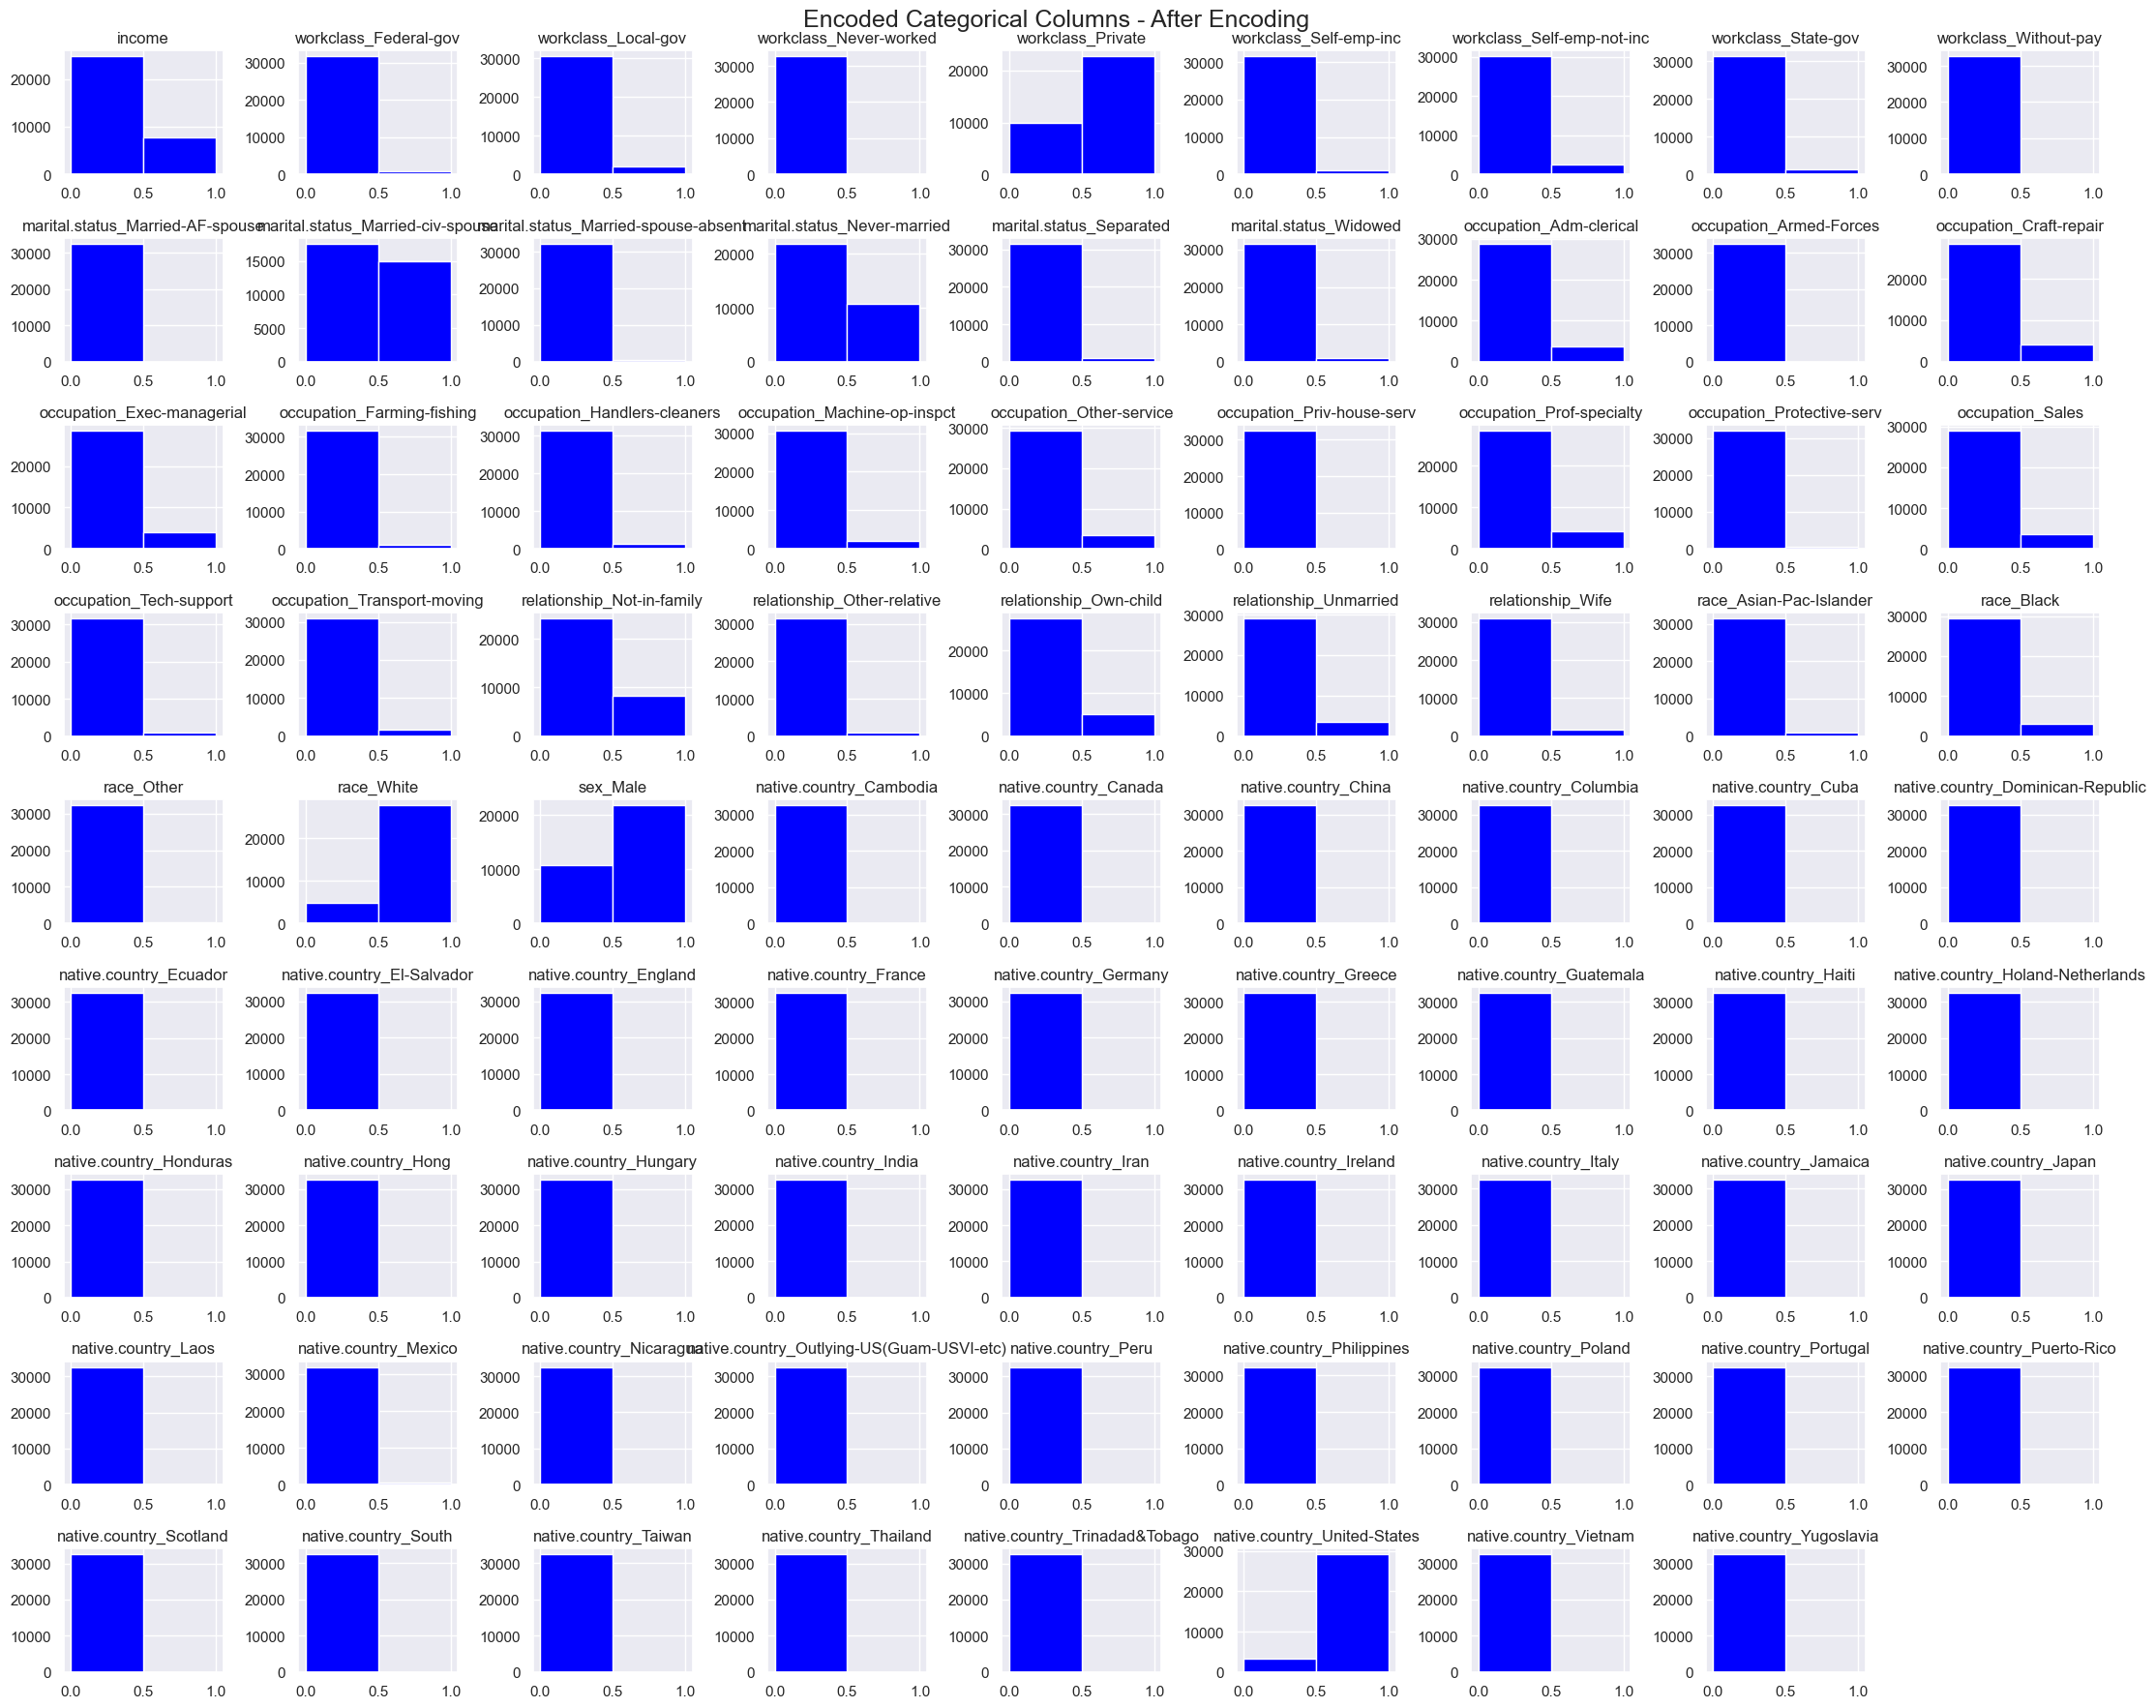

In [19]:
numeric_original_cols = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
]

encoded_cat_columns = [col for col in df_encoded.columns if col not in numeric_original_cols]


df_plot = df_encoded[encoded_cat_columns].astype(int)

df_plot.hist(figsize=(22, 18), bins=2, color="blue")
plt.suptitle("Encoded Categorical Columns - After Encoding", fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "IT25102219_Categorical_Columns_After_Encoding.png"), dpi=110)
plt.show()
plt.close()

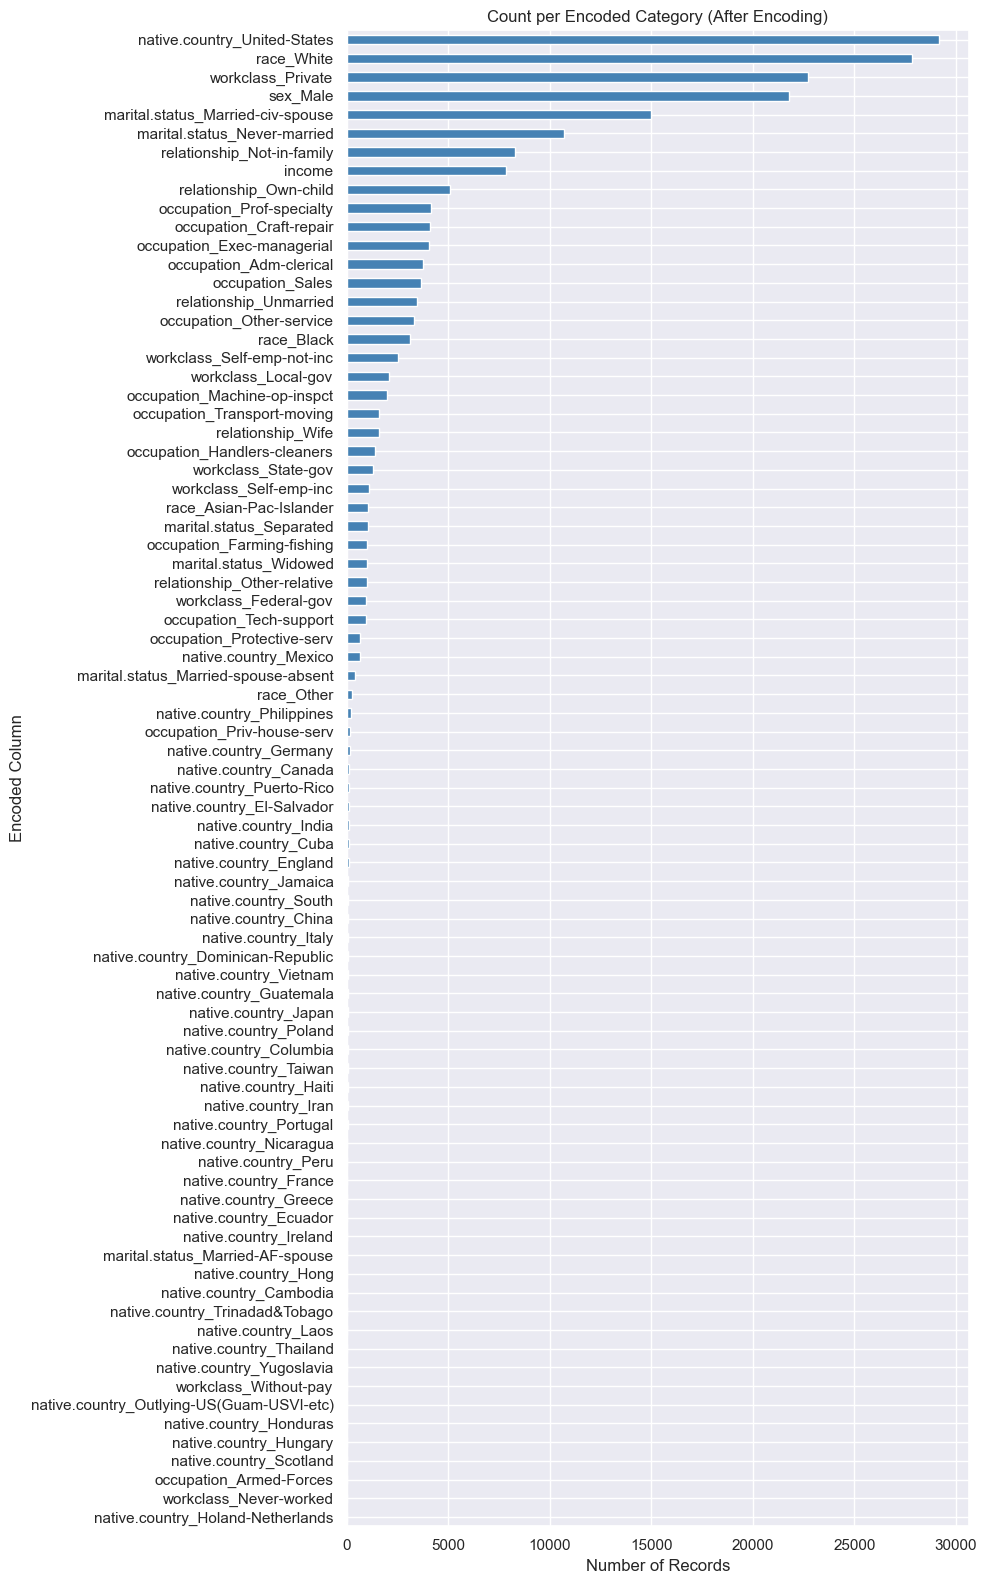

In [20]:
encoded_counts = df_encoded[encoded_cat_columns].sum().sort_values()

plt.figure(figsize=(10, 16))
encoded_counts.plot(kind="barh", color="steelblue")
plt.title("Count per Encoded Category (After Encoding)")
plt.xlabel("Number of Records")
plt.ylabel("Encoded Column")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "IT25102219_Categorical_Columns_Encoded_Category_Counts.png"), dpi=110)
plt.show()
plt.close()

## EDA interpretation

The before-encoding count plots show that the categorical variables have different numbers of levels and strongly different frequencies; `native.country` is especially concentrated in a small number of categories. After one-hot encoding, each indicator column represents membership in one category, and the after-encoding plots confirm that the categories have become numeric 0/1 features rather than ordinal codes. The encoded-category count plot also makes the frequency imbalance between common and rare categories visible, which is useful context when interpreting model performance.